In [10]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,
                          n_classes=2,n_clusters_per_class=1,random_state=41,
                          hypercube=False,class_sep=20)

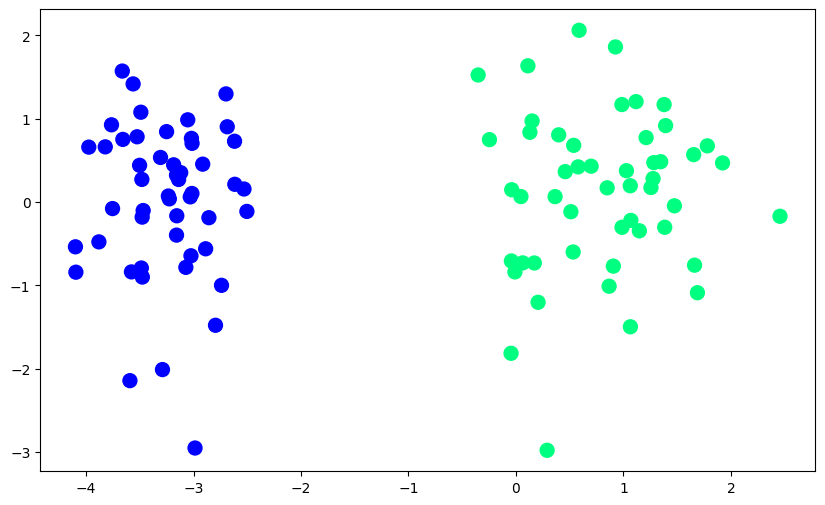

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)


In [15]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [16]:
print(lor.coef_)
print(lor.intercept_)

[[4.93404571 0.25053539]]
[5.8845279]


In [20]:
m1 = -(lor.coef_[0][0] / lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [22]:
x_input = np.linspace(-3,3,100)
y_input = m1 * x_input + b1

In [23]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

In [44]:
# This is Batch Gradient Descent
def gradientDescent(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.5
  epochs = 5500
  for i in range(epochs):
    y_hat = sigmoid(np.dot(X,weights))
    weights = weights + lr * np.dot((y-y_hat) , X) / X.shape[0]
  return weights[1:] , weights[0]

In [45]:
coef_ , intercept_ = gradientDescent(X,y)

In [46]:
coef_

array([4.90595446, 0.21769694])

In [47]:
intercept_

np.float64(5.928789389441727)

In [48]:
m = -(coef_[0] / coef_[1])
b = - (intercept_ / coef_[1])

In [49]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m * x_input1 + b

(-3.0, 2.0)

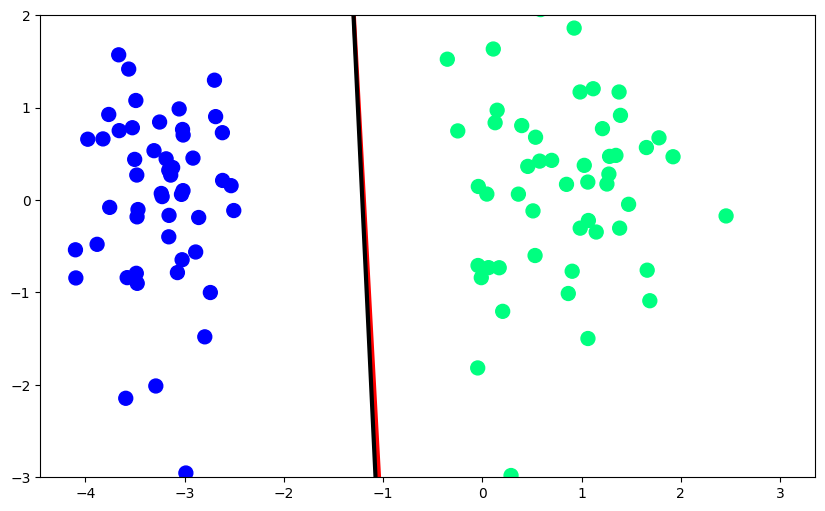

In [50]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)